In [ ]:
import pandas as pd
df=pd.read_csv('/content/telc_data.csv')
print(df.head())


   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [ ]:
print(df.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [ ]:
import pandas as pd
df=pd.read_csv('/content/telc_data.csv')
print(df['Churn'].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [ ]:
print(df['PaymentMethod'].value_counts())

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64


In [ ]:
print(pd.crosstab(df['Churn'],df['PaymentMethod']))

PaymentMethod  Bank transfer (automatic)  Credit card (automatic)  \
Churn                                                               
No                                  1286                     1290   
Yes                                  258                      232   

PaymentMethod  Electronic check  Mailed check  
Churn                                          
No                         1294          1304  
Yes                        1071           308  


In [ ]:
print(pd.crosstab(df['Contract'],df['Churn']))

Churn             No   Yes
Contract                  
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48


In [ ]:
print(pd.crosstab(df['InternetService'],df['Churn']))

Churn              No   Yes
InternetService            
DSL              1962   459
Fiber optic      1799  1297
No               1413   113


In [ ]:
print(pd.crosstab(df['SeniorCitizen'],df['Churn']))

Churn            No   Yes
SeniorCitizen            
0              4508  1393
1               666   476


In [ ]:
print(df.groupby('Churn')['tenure'].mean())

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64


In [ ]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')
print(df.groupby('Churn')['TotalCharges'].mean())

Churn
No     2555.344141
Yes    1531.796094
Name: TotalCharges, dtype: float64


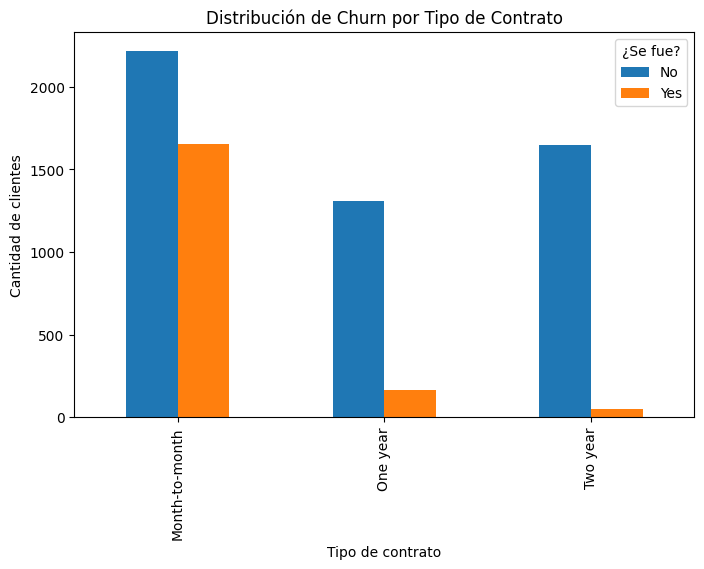

In [ ]:
import matplotlib.pyplot as plt
pd.crosstab(df['Contract'], df['Churn']).plot(kind='bar', figsize=(8,5))
plt.title('Distribución de Churn por Tipo de Contrato')
plt.xlabel('Tipo de contrato')
plt.ylabel('Cantidad de clientes')
plt.legend(title='¿Se fue?')
plt.show()

In [14]:
df['Churn'] = df['Churn'].replace({'Yes': 1, 'No': 0})
df['InternetService'] = df['InternetService'].replace({'DSL': 1, 'Fiber optic': 2, 'No': 0})
print(df[['Churn', 'InternetService']].head())

   Churn  InternetService
0      0                1
1      0                1
2      1                1
3      0                1
4      1                2


/tmp/ipykernel_19437/3286779211.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Churn'] = df['Churn'].replace({'Yes': 1, 'No': 0})
/tmp/ipykernel_19437/3286779211.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['InternetService'] = df['InternetService'].replace({'DSL': 1, 'Fiber optic': 2, 'No': 0})


In [15]:
from sklearn.model_selection import train_test_split

X = df[['InternetService']]
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Datos separados correctamente.")
print("Tamaño del grupo de entrenamiento:", len(X_train))

Datos separados correctamente.
Tamaño del grupo de entrenamiento: 5634


In [16]:
import os
os.makedirs('data/processed', exist_ok=True)

df.to_csv('data/processed/dataset_limpio.csv', index=False)
print("Archivo guardado correctamente en data/processed/")

Archivo guardado correctamente en data/processed/


In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

modelo = RandomForestClassifier(random_state=42)

modelo.fit(X_train, y_train)

predicciones = modelo.predict(X_test)

f1 = f1_score(y_test, predicciones, average='macro')
print(f"Modelo entrenado. F1-Score: {f1:.2f}")

Modelo entrenado. F1-Score: 0.42


In [18]:
import joblib
from pathlib import Path

Path("models").mkdir(parents=True, exist_ok=True)

ruta_modelo = Path("models/modelo_final.pkl")
joblib.dump(modelo, ruta_modelo)

print(f"Modelo guardado exitosamente en: {ruta_modelo}")

Modelo guardado exitosamente en: models/modelo_final.pkl


In [19]:
import json

metadata = {
    "modelo": "RandomForestClassifier",
    "version": "1.0",
    "metrica_principal": "f1_score_macro",
    "valor_metrica": round(f1, 2),
    "observaciones": "Entrenado con sklearn, semilla 42"
}

with open('models/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)

print("Metadatos guardados correctamente en models/model_metadata.json")

Metadatos guardados correctamente en models/model_metadata.json


In [20]:
from sklearn.tree import DecisionTreeClassifier

modelo_2 = DecisionTreeClassifier(random_state=42)
modelo_2.fit(X_train, y_train)

predicciones_2 = modelo_2.predict(X_test)
f1_2 = f1_score(y_test, predicciones_2, average='macro')

print(f"Modelo 1 (RandomForest) F1-Score: {f1:.2f}")
print(f"Modelo 2 (DecisionTree) F1-Score: {f1_2:.2f}")

if f1_2 > f1:
    print("Resultado: El Árbol de decisión es superior. Guardando como modelo final.")
    joblib.dump(modelo_2, 'models/modelo_final.pkl')
else:
    print("Resultado: RandomForest mantiene mejor rendimiento. Modelo previo preservado.")

Modelo 1 (RandomForest) F1-Score: 0.42
Modelo 2 (DecisionTree) F1-Score: 0.42
Resultado: RandomForest mantiene mejor rendimiento. Modelo previo preservado.


In [21]:
import os
print("Contenido de mi carpeta:")
print(os.listdir('.'))

if os.path.exists('models'):
    print("\nContenido de la carpeta 'models':")
    print(os.listdir('models'))
else:
    print("\nLa carpeta 'models' aún no existe.")

Contenido de mi carpeta:
['.config', 'data', 'models', 'telc_data.csv', 'sample_data']

Contenido de la carpeta 'models':
['model_metadata.json', 'modelo_final.pkl']
